interactive(children=(FloatSlider(value=1.0, description='k1', max=3.0, min=-3.0), FloatSlider(value=-1.0, des…

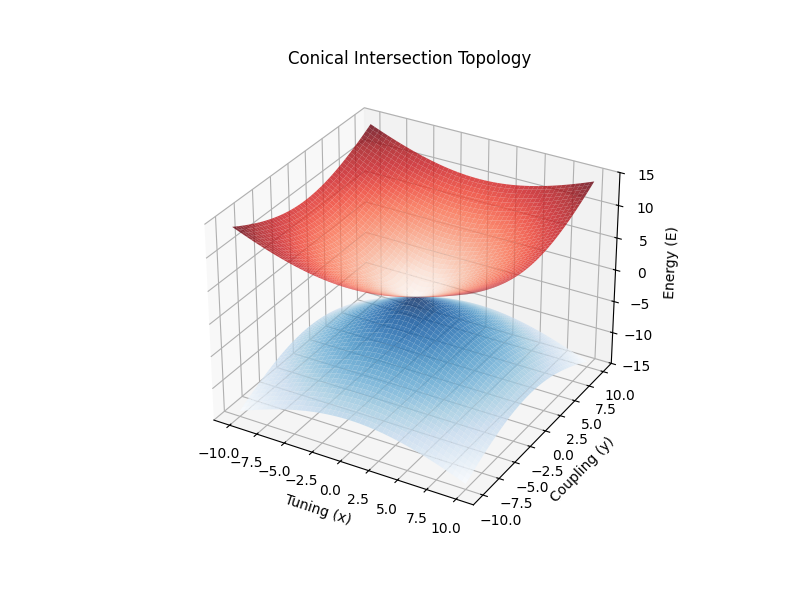

In [ ]:
# Run this in a Jupyter Notebook cell
# You may need to run: pip install ipympl ipywidgets

%matplotlib widget 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import ipywidgets as widgets
from IPython.display import display

# Create the grid
x = np.linspace(-10, 10, 300)
y = np.linspace(-10, 10, 300)
X, Y = np.meshgrid(x, y)

# Set up the figure and 3D axis
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
fig.canvas.toolbar_visible = False # Cleans up the UI

def update_plot(k1=1.0, k2=-1.0, lam=1.0):
    ax.clear() # Clear previous surfaces
    
    # Physics Calculation
    tilt = 0.5 * (k1 + k2) * X
    gap = np.sqrt((0.5 * (k1 - k2) * X)**2 + (lam * Y)**2)
    
    Z_upper = tilt + gap
    Z_lower = tilt - gap
    
    # Plot surfaces
    ax.plot_surface(X, Y, Z_upper, cmap='Reds', alpha=0.8, edgecolor='none')
    ax.plot_surface(X, Y, Z_lower, cmap='Blues', alpha=0.8, edgecolor='none')
    
    # Formatting
    ax.set_xlabel('Tuning (x)')
    ax.set_ylabel('Coupling (y)')
    ax.set_zlabel('Energy (E)')
    ax.set_zlim(-15, 15)
    ax.set_title("Conical Intersection Topology")
    
    # Force drawing update
    fig.canvas.draw_idle()

# Create interactive sliders
interactive_plot = widgets.interactive(
    update_plot, 
    k1=(-10.0, 10.0, 0.1), 
    k2=(-10.0, 10.0, 0.1), 
    lam=(0.0, 10.0, 0.1)
)

# Display the sliders and the plot
display(interactive_plot)